In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class ParametricMatrixModel(torch.nn.Module):
    def __init__(self, matrix_size=2):
        super().__init__()
        self.matrix_size = matrix_size
        num_params = (matrix_size * (matrix_size + 1)) // 2  # Symmetric matrix parameters
        
        # Initialize parameters for M0 and M1 matrices
        self.M0 = torch.nn.Parameter(torch.randn(num_params))
        self.M1 = torch.nn.Parameter(torch.randn(num_params))

    def build_matrix(self, params):
        """Construct symmetric matrix from packed parameters"""
        matrix = torch.zeros((self.matrix_size, self.matrix_size))
        idx = 0
        for i in range(self.matrix_size):
            for j in range(i, self.matrix_size):
                matrix[i,j] = matrix[j,i] = params[idx]
                idx += 1
        return matrix

    def forward(self, x):
        # x shape: (batch_size, 1)
        batch_size = x.shape[0]
        
        # Build M0 and M1 matrices
        M0 = self.build_matrix(self.M0)
        M1 = self.build_matrix(self.M1)
        
        # Create batch of matrices: M(x) = M0 + x*M1
        M = M0.unsqueeze(0) + x.view(-1, 1, 1) * M1.unsqueeze(0)
        
        # Compute eigenvalues (ascending order)
        eigenvalues = torch.linalg.eigh(M)[0]
        
        # Return smallest eigenvalue
        return eigenvalues[:, 0]

In [ ]:
def train_pmm(model, X, y, epochs=1000, lr=0.01):
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    X_tensor = torch.tensor(X, dtype=torch.float32).view(-1, 1)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        if epoch % 100 == 0:
            print(f'Epoch {epoch:4d} | Loss: {loss.item():.4f}')
    
    return losses

In [46]:
def test_function(x):
    return 2 * x + 0.5

In [48]:
# Generate training data
X = np.linspace(-1, 1, 100)
y = test_function(X)

# Initialize and train PMM
pmm = ParametricMatrixModel(matrix_size=2)
losses = train_pmm(pmm, X, y, epochs=1000, lr=0.01)

# Test prediction
with torch.no_grad():
    test_X = np.linspace(-1, 1, 100)
    pred_y = pmm(torch.tensor(test_X, dtype=torch.float32).view(-1, 1)).numpy()

Epoch    0 | Loss: 2.2321
Epoch  100 | Loss: 0.3272
Epoch  200 | Loss: 0.0260
Epoch  300 | Loss: 0.0027
Epoch  400 | Loss: 0.0006
Epoch  500 | Loss: 0.0002
Epoch  600 | Loss: 0.0001
Epoch  700 | Loss: 0.0000
Epoch  800 | Loss: 0.0000
Epoch  900 | Loss: 0.0000


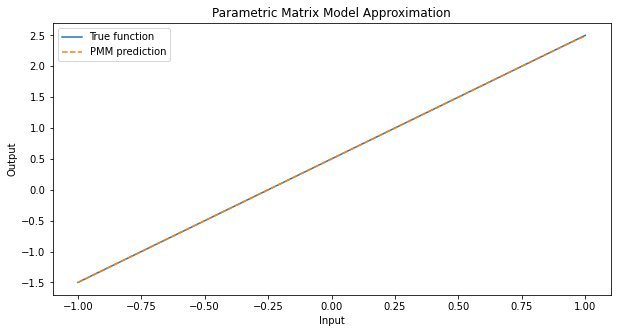

In [49]:
# Plot results
plt.figure(figsize=(10, 5))
plt.plot(test_X, test_function(test_X), label='True function')
plt.plot(test_X, pred_y, '--', label='PMM prediction')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Parametric Matrix Model Approximation')
plt.legend()
plt.show()

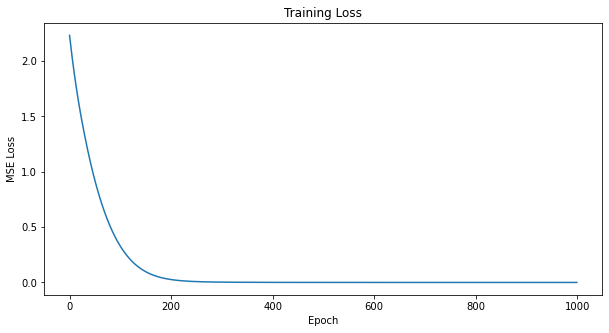

In [52]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.show()